In [1]:
%matplotlib inline

import networkx as nx
import matplotlib.pyplot as plt
from scipy.io import mmread
import numpy as np
import community.community_louvain as louvain
import collections
import operator

In [2]:
data = mmread("inf-USAir97.mtx")
G = nx.Graph(data)

In [3]:
#@inproceedings{nr-aaai15,
#     title = {The Network Data Repository with Interactive Graph Analytics and Visualization},
#     author={Ryan A. Rossi and Nesreen K. Ahmed},
#     booktitle = {Proceedings of the Twenty-Ninth AAAI Conference on Artificial Intelligence},
#     url={http://networkrepository.com},
#     year={2015}
#}

In [4]:
"""Show the number of nodes and edges in the graph"""
print("Number of nodes : ",len(G.nodes()))
print("Number of edges : ",len(G.edges()))

Number of nodes :  332
Number of edges :  2126


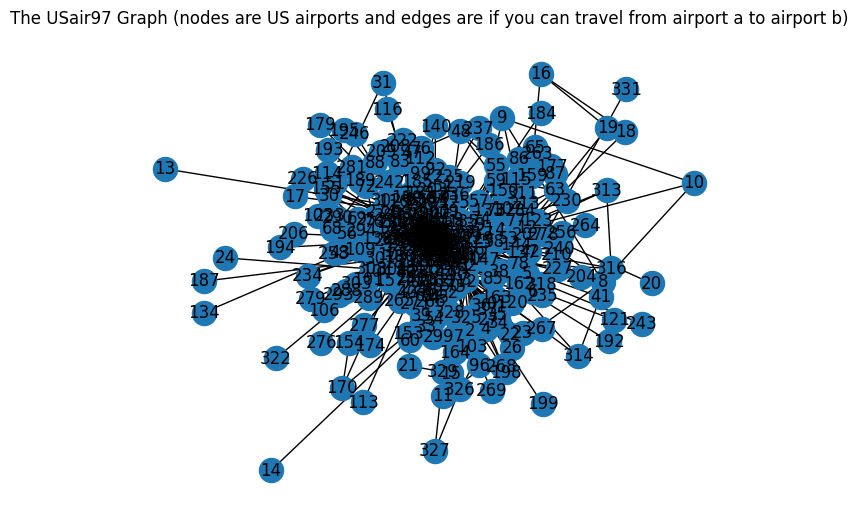

In [5]:
"""Draw the graph"""
nx.draw(G, with_labels=True)
plt.title("The USair97 Graph (nodes are US airports and edges are if you can travel from airport a to airport b)")
plt.show()

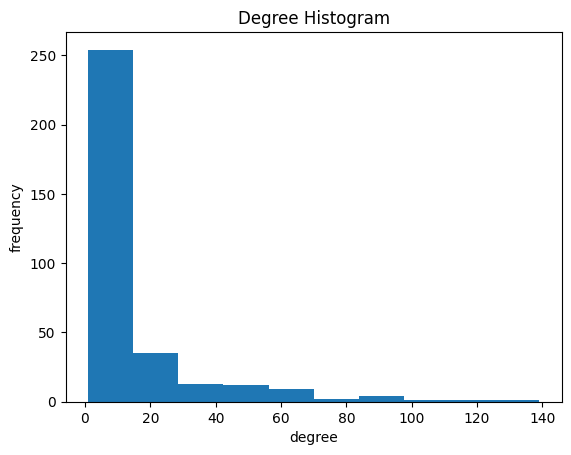

In [6]:
"""Draw the histogram of degrees"""
deg_seq = [G.degree(x) for x in nx.nodes(G)]
plt.hist(deg_seq)
plt.title('Degree Histogram')
plt.xlabel('degree')
plt.ylabel('frequency')
plt.show()

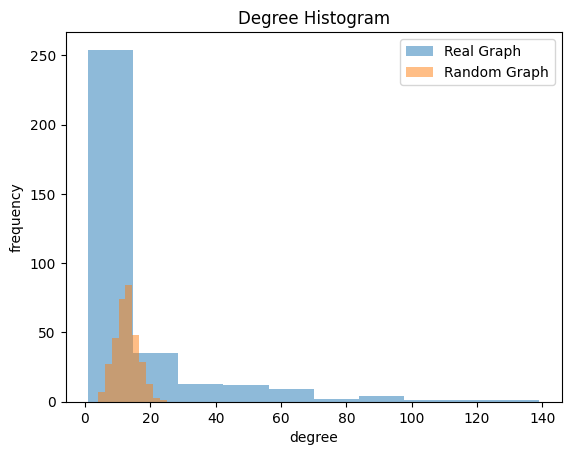

USAir97 Network:
Average Degree: 12.80722891566265

Random Graph:
Average Degree: 12.783132530120483


In [7]:
"""Compare the distribution with the distribution for a random graph having the same average degree. Discuss the results."""
avg_degree = sum(dict(G.degree()).values()) / len(G)
n = len(G)
p = avg_degree / (n - 1)
random_G = nx.erdos_renyi_graph(n, p)

G_degrees = dict(G.degree()).values()
randG_degrees = dict(random_G.degree()).values()

plt.hist(G_degrees, alpha=0.5, label='Real Graph')
plt.hist(randG_degrees, alpha=0.5, label='Random Graph')
plt.legend(loc='upper right')
plt.title('Degree Histogram')
plt.xlabel('degree')
plt.ylabel('frequency')
plt.show()


print("USAir97 Network:")
print("Average Degree:", np.mean(list(G_degrees)))

print("\nRandom Graph:")
print("Average Degree:", np.mean(list(randG_degrees)))

**As we can see on the degree distribution of these two graphs, in the real life graph, there are really few nodes that have a really high degree and a majority of nodes that have small degree
Also, we can see that the random graph is a lot more heterogenous, as all nodes have most likely not a big difference in degree, which is most of the case in random graphs**

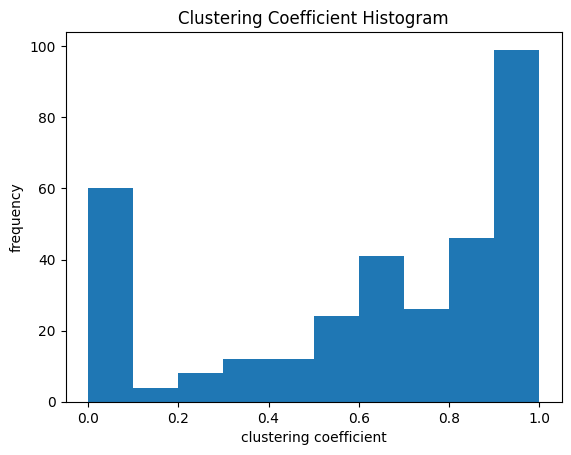

Average Clustering Coefficient: 0.625217249162503


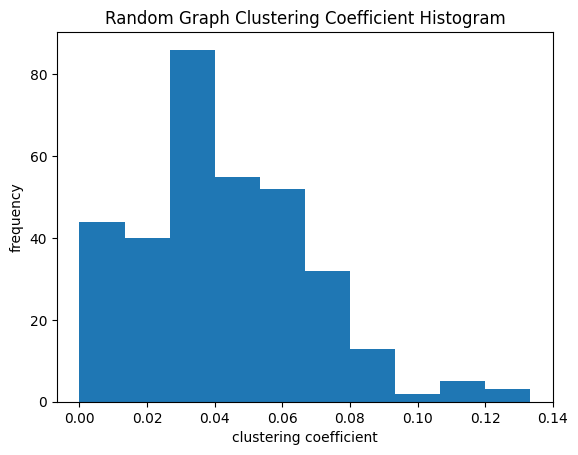

Random Graph Average Clustering Coefficient :  0.0425315263874143


In [8]:
"""Draw the histogram of clustering coefficient, and the average clustering coefficient"""
clustering_coeffs = list(nx.clustering(G).values())
plt.hist(clustering_coeffs)
plt.title('Clustering Coefficient Histogram')
plt.xlabel('clustering coefficient')
plt.ylabel('frequency')
plt.show()

avg_clustering_coeff = nx.average_clustering(G)
print(f"Average Clustering Coefficient: {avg_clustering_coeff}")

"""Compare it with the one of a random graph and discuss the results"""
randG_clustering_coeffs = list(nx.clustering(random_G).values())
plt.hist(randG_clustering_coeffs)
plt.title('Random Graph Clustering Coefficient Histogram')
plt.xlabel('clustering coefficient')
plt.ylabel('frequency')
plt.show()

randG_avg_clustering_coeff = nx.average_clustering(random_G)
print("Random Graph Average Clustering Coefficient : ",randG_avg_clustering_coeff)

**As we can see, in the real graph, the clustering coefficient are widely distributed between 0 and 1 which shows that the graph nodes are tightly connected.**

**While in the random graph, the clustering coefficient is concentrated between 0 and 0.1 with a few nodes with more than 0.1 which means that the nodes are loosely connected in this graph.**

**This shows that the real graph is well structured with logical connection while the random graph shows a lack of structure and we can see the limits of random graphs in modeling real world network**

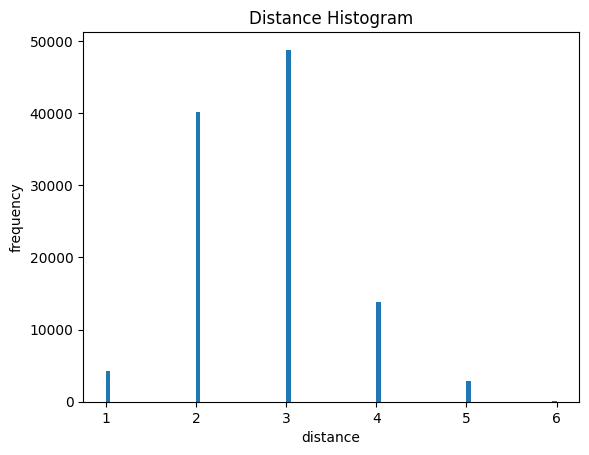

Diameter :  6
Average Distance :  2.7381247042550867


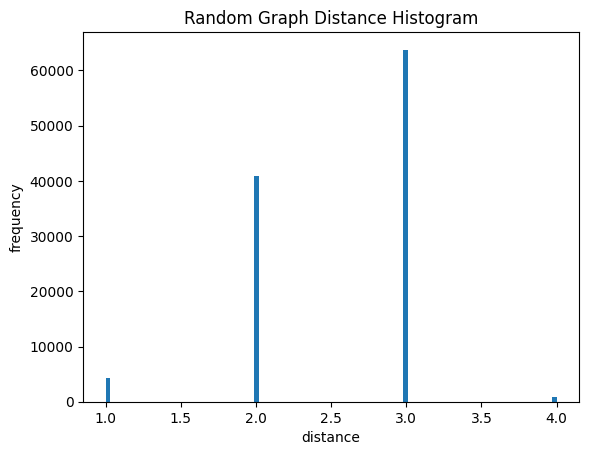

Random Graph Diameter :  4
Random GraphAverage Distance :  2.558784988898191


In [9]:
"""Draw the histogram of distances in the graphs, the diameter and the average distance"""
distances = dict(nx.all_pairs_shortest_path_length(G))

all_distances = []
for node1, paths in distances.items():
    for node2, length in paths.items():
        if node1 != node2:  # Exclude distances from a node to itself
            all_distances.append(length)

plt.hist(all_distances, bins=100)
plt.title('Distance Histogram')
plt.xlabel('distance')
plt.ylabel('frequency')
plt.show()

diameter = max(all_distances)


avg_distance = sum(all_distances) / len(all_distances)

print("Diameter : ",diameter)
print("Average Distance : ",avg_distance)




"""same but with the random graph"""

randomG_distances = dict(nx.all_pairs_shortest_path_length(random_G))

randomG_all_distances = []
for node1, paths in randomG_distances.items():
    for node2, length in paths.items():
        if node1 != node2:  # Exclude distances from a node to itself
            randomG_all_distances.append(length)

plt.hist(randomG_all_distances, bins=100)
plt.title('Random Graph Distance Histogram')
plt.xlabel('distance')
plt.ylabel('frequency')
plt.show()

randomG_diameter = max(randomG_all_distances)


randomG_avg_distance = sum(randomG_all_distances) / len(randomG_all_distances)

print("Random Graph Diameter : ",randomG_diameter)
print("Random GraphAverage Distance : ",randomG_avg_distance)

In [10]:
"""Analyze the degree correlations of the graph. """
degree_correlation = nx.degree_assortativity_coefficient(G)
print("Degree Correlation : ", degree_correlation)

Degree Correlation :  -0.2078762308120043


**We can see that the degree correlation of this graph is negative, which let us think that high degree nodes tend to connect to low degree nodes (which is logic when you think about a big state airport in the US that serves small states airports)**

In [11]:
"""Detect the communities in the graph, and discuss the results."""
partition_G = louvain.best_partition(G)
num_communities = len(set(partition_G.values()))
community_sizes = collections.Counter(partition_G.values())

print("Number of communities :", num_communities)
for community_id, size in community_sizes.items():
    print("Community", community_id, ": Size", size)

Number of communities : 5
Community 0 : Size 91
Community 4 : Size 43
Community 2 : Size 105
Community 3 : Size 60
Community 1 : Size 33


**The Louvain algorithm has identified a certain number of communities within the USAir97 network.  The output shows the number of communities found and the size of each. A higher number of smaller communities might suggest a decentralized network structure where airports are grouped into regional clusters.  Conversely, a smaller number of larger communities could indicate a more centralized network with a few major hubs connecting different regions.**



**Now we can visualize the graph with nodes colored according to their community assignment. This provides a visual representation of the detected communities. We Use the `partition_G` dictionary to color the nodes accordingly.**


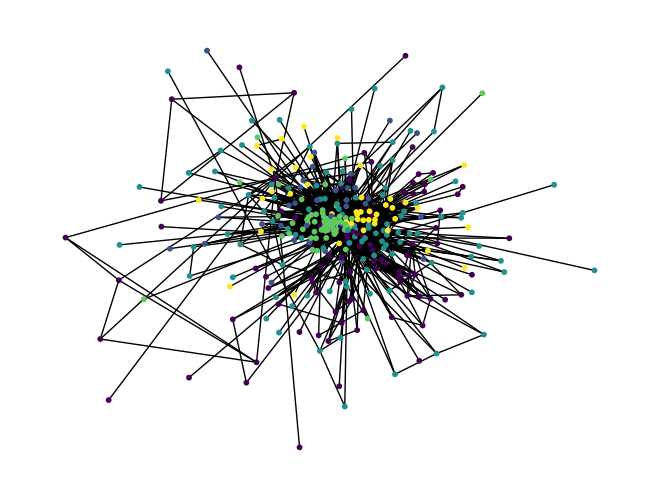

In [12]:
nx.draw(G, node_color=[partition_G[node] for node in G.nodes()], with_labels=False, node_size=10)
plt.show()

**We can also calculate the modularity score of the resulting partition. A higher modularity indicates a better community structure.**

In [13]:
"""Calculate modularity score"""
modularity = louvain.modularity(partition_G, G)
print(f"Modularity: {modularity}")

Modularity: 0.19912643383979806


**For better analysis , we can also deep dive into the characteristics of the different communities (we measured the average degree and clustering coefficient of each community).**

In [14]:
"""Analyze community characteristics """
community_stats = {}
for community_id in set(partition_G.values()):
    community_nodes = [node for node, comm in partition_G.items() if comm == community_id]
    subgraph = G.subgraph(community_nodes)

    avg_degree = np.mean(list(dict(subgraph.degree()).values())) if subgraph.number_of_nodes()>0 else 0
    clustering_coeff = nx.average_clustering(subgraph) if subgraph.number_of_nodes()>0 else 0

    community_stats[community_id] = {
        'size': len(community_nodes),
        'avg_degree': avg_degree,
        'clustering_coeff': clustering_coeff
    }

for community_id, stats in community_stats.items():
    print(f"Community {community_id}:")
    print(f"  Size: {stats['size']}")
    print(f"  Average Degree: {stats['avg_degree']}")
    print(f"  Clustering Coefficient: {stats['clustering_coeff']}")

Community 0:
  Size: 91
  Average Degree: 5.142857142857143
  Clustering Coefficient: 0.6119712868026795
Community 1:
  Size: 33
  Average Degree: 4.121212121212121
  Clustering Coefficient: 0.5591075591075592
Community 2:
  Size: 105
  Average Degree: 4.285714285714286
  Clustering Coefficient: 0.515939452958166
Community 3:
  Size: 60
  Average Degree: 15.766666666666667
  Clustering Coefficient: 0.6095799740274237
Community 4:
  Size: 43
  Average Degree: 4.651162790697675
  Clustering Coefficient: 0.39709476768002905


**We can see that community 4 has a significantly higher average degree compared to other communities, it suggests that nodes within this community have more connections to other nodes within the same community. This could indicate a dense, well-connected cluster.
Also community 4 has a high clustering coefficient in comparison with two other communities with bigger size (Community 2 : Size  102  & Community 0 : Size 91 )it means nodes within this community tend to form triangles, or clusters of highly interconnected nodes. This suggests a strong local structure within community 4. We can conclude from comparison of these values, community 4 is denser, more connected, or more locally clustered than the rest.**

**Now we will compare the community characteristics of our data with a random graph generated by P. Erdős and A.Rényi algorithms.**

In [15]:
"""Community comparison with random graph"""
random_G = nx.erdos_renyi_graph(n, p)
random_partition = louvain.best_partition(random_G)
random_num_communities = len(set(random_partition.values()))
random_community_sizes = collections.Counter(random_partition.values())


print("\nRandom Graph Community Analysis:")
print("Number of communities:", random_num_communities)
for community_id, size in random_community_sizes.items():
  print("Community", community_id, ": Size", size)

random_community_stats = {}
for community_id in set(random_partition.values()):
    community_nodes = [node for node, comm in random_partition.items() if comm == community_id]
    subgraph = random_G.subgraph(community_nodes)

    avg_degree = np.mean(list(dict(subgraph.degree()).values())) if subgraph.number_of_nodes()>0 else 0
    clustering_coeff = nx.average_clustering(subgraph) if subgraph.number_of_nodes()>0 else 0

    random_community_stats[community_id] = {
        'size': len(community_nodes),
        'avg_degree': avg_degree,
        'clustering_coeff': clustering_coeff
    }

for community_id, stats in random_community_stats.items():
    print(f"Random Graph Community {community_id}:")
    print(f"  Size: {stats['size']}")
    print(f"  Average Degree: {stats['avg_degree']}")
    print(f"  Clustering Coefficient: {stats['clustering_coeff']}")


Random Graph Community Analysis:
Number of communities: 10
Community 0 : Size 28
Community 1 : Size 50
Community 2 : Size 39
Community 3 : Size 37
Community 4 : Size 42
Community 5 : Size 19
Community 6 : Size 39
Community 7 : Size 16
Community 9 : Size 38
Community 8 : Size 24
Random Graph Community 0:
  Size: 28
  Average Degree: 4.214285714285714
  Clustering Coefficient: 0.23653628117913833
Random Graph Community 1:
  Size: 50
  Average Degree: 5.8
  Clustering Coefficient: 0.09404761904761905
Random Graph Community 2:
  Size: 39
  Average Degree: 4.512820512820513
  Clustering Coefficient: 0.15809930809930808
Random Graph Community 3:
  Size: 37
  Average Degree: 4.594594594594595
  Clustering Coefficient: 0.14079794079794086
Random Graph Community 4:
  Size: 42
  Average Degree: 4.809523809523809
  Clustering Coefficient: 0.06345427059712774
Random Graph Community 5:
  Size: 19
  Average Degree: 3.263157894736842
  Clustering Coefficient: 0.23684210526315794
Random Graph Communi

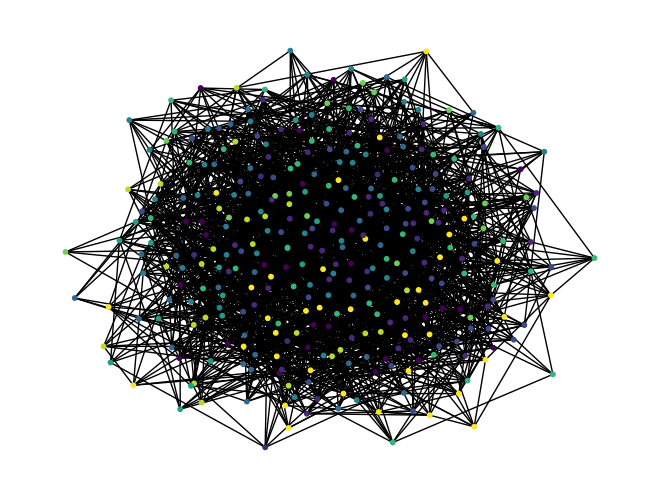

In [16]:
nx.draw(random_G, node_color=[random_partition[node] for node in random_G.nodes()], with_labels=False, node_size=10)
plt.show()

In [17]:
"""Calculate modularity score of random graph"""
random_modularity = louvain.modularity(random_partition, random_G)
print(f"Random Graph Modularity: {random_modularity}")

Random Graph Modularity: 0.2429249154672557


In [18]:
"""Calculate average clustering coefficient for the original graph"""
clustering_coeffs_original = [stats['clustering_coeff'] for stats in community_stats.values()]
avg_clustering_coeff_original = np.mean(clustering_coeffs_original)

"""Calculate average clustering coefficient for the random graph"""
clustering_coeffs_random = [stats['clustering_coeff'] for stats in random_community_stats.values()]
avg_clustering_coeff_random = np.mean(clustering_coeffs_random)

"""Calculate and print the difference"""
print(f"\nAverage Clustering Coefficient Difference: {avg_clustering_coeff_original - avg_clustering_coeff_random}")


Average Clustering Coefficient Difference: 0.36927356366892405


The analysis of community statistics between the original graph (USAir97) and the random graph reveals significant differences, highlighting the non-random nature of the real-world airline network.

1. Community size : in the original graph exhibit greater variance compared to the more uniform distribution observed in the random graph's communities."

2.   Average Degree: The original graph's communities demonstrate a wider range of average degrees, indicating varying levels of connectivity within each community.  In contrast, the random graph's communities tend to have more homogeneous average degrees, reflecting the random nature of its connections.


3.   Clustering Coefficient: The original graph's communities display substantially higher clustering coefficients than the random graph's communities. This suggests that nodes within communities of the original graph tend to form dense clusters with high local connectivity, a pattern not observed in the random graph.

Overall, The differences in community statistics underscore the importance of considering real-world network structures rather than assuming randomness. The non-random characteristics observed in the USAir97 network, such as varying community sizes and higher clustering coefficients, indicate a structure indicative of regional hubs and routes.







# Other Interesting Analysis:Measure Centrality


In [19]:
"""Analyze the betweenness centrality of the nodes"""
betweenness_centrality = nx.betweenness_centrality(G)
print("Betweenness Centrality : ",betweenness_centrality)

Betweenness Centrality :  {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0007596442612616646, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.17006973867446298, 8: 6.103329366169245e-06, 9: 6.103329366169245e-06, 10: 0.0, 11: 0.0, 12: 0.06529952088864475, 13: 0.0, 14: 0.0, 15: 0.0009607836101001456, 16: 0.0, 17: 0.0, 18: 0.0, 19: 0.0, 20: 0.0, 21: 4.6995636119503196e-05, 22: 0.0, 23: 0.0, 24: 0.0, 25: 0.01560027118163282, 26: 0.0, 27: 0.0, 28: 0.002404430880701304, 29: 0.0, 30: 0.00022704385242149587, 31: 6.103329366169245e-06, 32: 0.005796942231987548, 33: 0.0, 34: 9.154994049253868e-06, 35: 9.154994049253868e-06, 36: 0.0, 37: 9.154994049253868e-06, 38: 0.0, 39: 0.000159010957011661, 40: 0.0, 41: 0.0, 42: 0.0, 43: 0.0, 44: 0.00814758625267087, 45: 0.000137103416438381, 46: 0.09281838103560958, 47: 2.197198571820928e-05, 48: 1.220665873233849e-05, 49: 0.0009995787073158238, 50: 0.0, 51: 0.0, 52: 3.2216860011421945e-05, 53: 2.9753730660075078e-05, 54: 0.00016162666959716217, 55: 3.417864445054777e-05, 56: 1.52583234154231

In [20]:
"""Find the top 10 nodes with highest betweenness centrality"""
sorted_betweenness = dict(sorted(betweenness_centrality.items(), key=operator.itemgetter(1), reverse=True))
top_10_nodes = list(sorted_betweenness.keys())[:10]

print("Top 10 nodes with highest betweenness centrality:")
for node in top_10_nodes:
    print(f"Node {node}: Betweenness Centrality = {betweenness_centrality[node]}")

Top 10 nodes with highest betweenness centrality:
Node 117: Betweenness Centrality = 0.2083058698588695
Node 7: Betweenness Centrality = 0.17006973867446298
Node 260: Betweenness Centrality = 0.15319554114303377
Node 200: Betweenness Centrality = 0.09422863574735518
Node 46: Betweenness Centrality = 0.09281838103560958
Node 181: Betweenness Centrality = 0.08154651640084307
Node 254: Betweenness Centrality = 0.0714996794236738
Node 151: Betweenness Centrality = 0.0693048644517428
Node 312: Betweenness Centrality = 0.06812667347801997
Node 12: Betweenness Centrality = 0.06529952088864475


In [21]:
"""Calculate degree centrality"""
degree_centrality = nx.degree_centrality(G)
print("Degree Centrality : ",degree_centrality)

Degree Centrality :  {0: 0.00906344410876133, 1: 0.00906344410876133, 2: 0.006042296072507553, 3: 0.015105740181268881, 4: 0.006042296072507553, 5: 0.00906344410876133, 6: 0.00906344410876133, 7: 0.08761329305135952, 8: 0.012084592145015106, 9: 0.012084592145015106, 10: 0.00906344410876133, 11: 0.00906344410876133, 12: 0.04229607250755287, 13: 0.0030211480362537764, 14: 0.0030211480362537764, 15: 0.006042296072507553, 16: 0.00906344410876133, 17: 0.0030211480362537764, 18: 0.00906344410876133, 19: 0.00906344410876133, 20: 0.0030211480362537764, 21: 0.006042296072507553, 22: 0.006042296072507553, 23: 0.006042296072507553, 24: 0.0030211480362537764, 25: 0.02416918429003021, 26: 0.0030211480362537764, 27: 0.006042296072507553, 28: 0.012084592145015106, 29: 0.006042296072507553, 30: 0.00906344410876133, 31: 0.006042296072507553, 32: 0.012084592145015106, 33: 0.006042296072507553, 34: 0.00906344410876133, 35: 0.00906344410876133, 36: 0.006042296072507553, 37: 0.00906344410876133, 38: 0.0090

In [22]:
"""Find the top 10 nodes with highest degree centrality"""
sorted_degree_centrality = dict(sorted(degree_centrality.items(), key=operator.itemgetter(1), reverse=True))
top_10_nodes = list(sorted_degree_centrality.keys())[:10]

print("Top 10 nodes with highest degree centrality:")
for node in top_10_nodes:
    print(f"Node {node}: Degree Centrality = {degree_centrality[node]}")

Top 10 nodes with highest degree centrality:
Node 117: Degree Centrality = 0.4199395770392749
Node 260: Degree Centrality = 0.3564954682779456
Node 254: Degree Centrality = 0.30513595166163143
Node 151: Degree Centrality = 0.283987915407855
Node 181: Degree Centrality = 0.283987915407855
Node 229: Degree Centrality = 0.2628398791540785
Node 165: Degree Centrality = 0.256797583081571
Node 66: Degree Centrality = 0.23564954682779457
Node 111: Degree Centrality = 0.21148036253776434
Node 200: Degree Centrality = 0.2054380664652568


**Nodes with high betweenness centrality act as bridges, connecting different parts of the network.  Nodes with high degree centrality are important hubs, with many connections to other nodes in the network.**

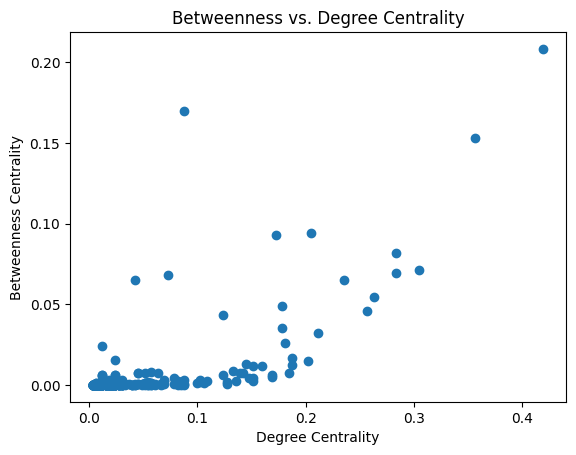

In [23]:
"""Compare betweenness centrality with degree centrality"""
# Plot betweenness vs. degree.
plt.scatter(list(degree_centrality.values()), list(betweenness_centrality.values()))
plt.xlabel("Degree Centrality")
plt.ylabel("Betweenness Centrality")
plt.title("Betweenness vs. Degree Centrality")
plt.show()

In [24]:
"""Calculate the Pearson correlation coefficient between degree and betweenness centrality"""
correlation = np.corrcoef(list(degree_centrality.values()), list(betweenness_centrality.values()))[0, 1]
print(f"Pearson correlation between degree and betweenness centrality: {correlation}")

Pearson correlation between degree and betweenness centrality: 0.7043755657222832


The positive correlation between degree centrality and betweenness centrality observed in our graph data (and often in real-world networks) arises because nodes with many connections (high degree centrality) are more likely to lie on shortest paths between other nodes.

As we know:

* **Degree Centrality:** Measures the number of direct connections a node has.  A high-degree node is a hub, connected to many other nodes.

* **Betweenness Centrality:** Measures the number of times a node lies on the shortest path between two other nodes.  A node with high betweenness centrality is crucial for information or flow to traverse the network.

**Why the Correlation?**

A node with a high degree is likely to be part of many shortest paths.  For instnace,  a central airport (high degree):  many routes will go through it because it's directly connected to many other airports.  This puts it on the shortest paths for travelers going between those connected airports.

**Caveats:**

* **Not always perfect:** The correlation is not always a perfect 1.  A node could have a high degree but not lie on many shortest paths if those connections are redundant or form a densely-connected cluster. Conversely, a node with a moderate degree might have high betweenness centrality if it acts as a bridge between otherwise disconnected parts of the network.

* **Network structure matters:** The correlation strength depends on the network's structure.  In scale-free networks (like the one we analyzed), the correlation might be stronger. In other types of networks, the relationship might be weaker or even negative.

Also as we calculated the Pearson correlation coefficient to quantify the linear relationship between the two centralities.  A positive value (as observed in the above code) indicates that as degree centrality increases, betweenness centrality tends to increase as well, but it's not a deterministic relationship.


In [25]:
# Analyze the closeness centrality of the nodes.
closeness_centrality = nx.closeness_centrality(G)
print("Closeness Centrality : ",closeness_centrality)

Closeness Centrality :  {0: 0.3134469696969697, 1: 0.3134469696969697, 2: 0.31315042573320717, 3: 0.35861321776814736, 4: 0.31315042573320717, 5: 0.3167464114832536, 6: 0.3167464114832536, 7: 0.45467032967032966, 8: 0.2432035268185158, 9: 0.2432035268185158, 10: 0.24302496328928047, 11: 0.24302496328928047, 12: 0.32011605415860733, 13: 0.24266862170087977, 14: 0.24266862170087977, 15: 0.3134469696969697, 16: 0.24302496328928047, 17: 0.24266862170087977, 18: 0.24302496328928047, 19: 0.24302496328928047, 20: 0.24266862170087977, 21: 0.2654370489174018, 22: 0.31315042573320717, 23: 0.31315042573320717, 24: 0.26501200960768617, 25: 0.3601741022850925, 26: 0.31285444234404536, 27: 0.31315042573320717, 28: 0.3476890756302521, 29: 0.31315042573320717, 30: 0.26565008025682185, 31: 0.25859375, 32: 0.3476890756302521, 33: 0.31315042573320717, 34: 0.3134469696969697, 35: 0.3134469696969697, 36: 0.31315042573320717, 37: 0.3134469696969697, 38: 0.35100742311770944, 39: 0.34018499486125386, 40: 0.36

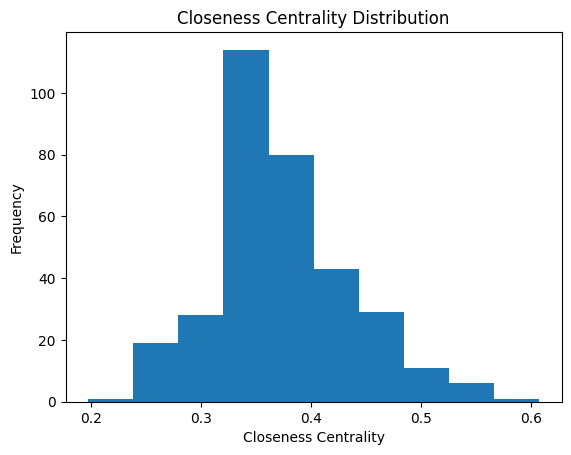

In [26]:
# Analyze the distribution of closeness centrality (histogram)
plt.hist(list(closeness_centrality.values()))
plt.xlabel("Closeness Centrality")
plt.ylabel("Frequency")
plt.title("Closeness Centrality Distribution")
plt.show()

In [27]:
"""Find the top 10 nodes with highest closeness centrality"""
sorted_close_centrality = dict(sorted(closeness_centrality.items(), key=operator.itemgetter(1), reverse=True))
top_10_nodes = list(sorted_close_centrality.keys())[:10]

print("Top 10 nodes with highest closeness centrality:")
for node in top_10_nodes:
    print(f"Node {node}: Closeness Centrality = {closeness_centrality[node]}")

Top 10 nodes with highest closeness centrality:
Node 117: Closeness Centrality = 0.6073394495412844
Node 260: Closeness Centrality = 0.5544388609715243
Node 66: Closeness Centrality = 0.5399673735725938
Node 254: Closeness Centrality = 0.5355987055016181
Node 200: Closeness Centrality = 0.533011272141707
Node 181: Closeness Centrality = 0.5287539936102237
Node 46: Closeness Centrality = 0.5262321144674086
Node 165: Closeness Centrality = 0.5245641838351822
Node 247: Closeness Centrality = 0.5245641838351822
Node 111: Closeness Centrality = 0.5237341772151899


**Closeness centrality measures the average shortest path distance from a node to all other reachable nodes in the graph.  A higher closeness centrality indicates that a node is closer to other nodes on average, suggesting it can quickly reach other parts of the network.  In other words, it's a measure of how "central" a node is in terms of its proximity to other nodes.**

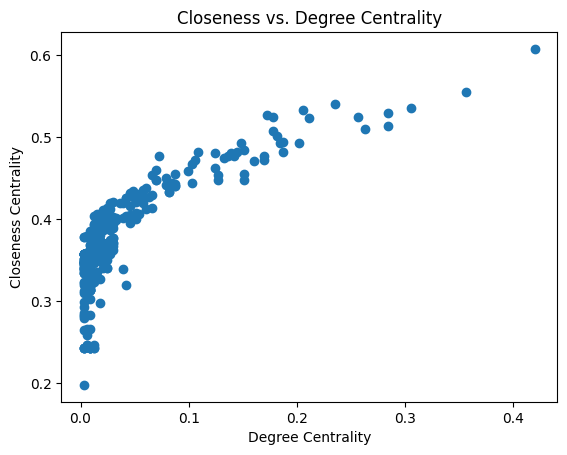

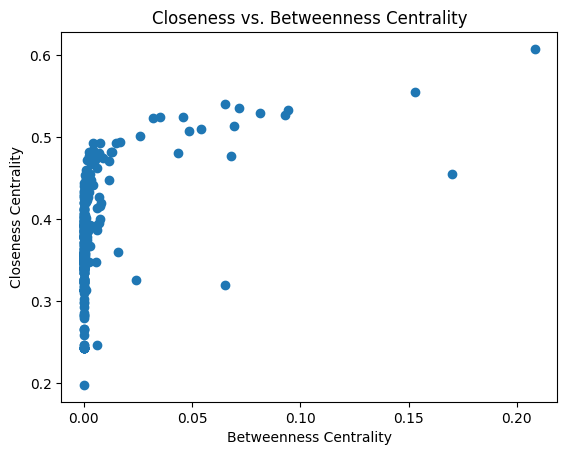

In [28]:
# Compare closeness centrality with other centrality measures (degree, betweenness)
plt.scatter(list(degree_centrality.values()), list(closeness_centrality.values()))
plt.xlabel("Degree Centrality")
plt.ylabel("Closeness Centrality")
plt.title("Closeness vs. Degree Centrality")
plt.show()

plt.scatter(list(betweenness_centrality.values()), list(closeness_centrality.values()))
plt.xlabel("Betweenness Centrality")
plt.ylabel("Closeness Centrality")
plt.title("Closeness vs. Betweenness Centrality")
plt.show()

In [29]:
# Calculate the Pearson correlation coefficient
correlation = np.corrcoef(list(degree_centrality.values()), list(closeness_centrality.values()))[0, 1]
print(f"Pearson correlation between degree and closeness centrality: {correlation}")

Pearson correlation between degree and closeness centrality: 0.8034147356539191


In [30]:
# Calculate the Pearson correlation coefficient
correlation = np.corrcoef(list(betweenness_centrality.values()), list(closeness_centrality.values()))[0, 1]
print(f"Pearson correlation between betweenness and closeness centrality: {correlation}")

Pearson correlation between betweenness and closeness centrality: 0.49436310159742947



Degree centrality and closeness centrality are correlated (as we can see the Pearson correlation between them as  above) because they both reflect a node's position within a network, although they do so in slightly different ways.  A node with a high degree centrality has many direct connections.  If those connections are well-placed within the network, it will also tend to have a short average path length to other nodes, leading to high closeness centrality.

In simpler terms:

* **High Degree Centrality:**  A node is a hub, directly connected to many others.
* **High Closeness Centrality:** A node is centrally located, with short paths to many other nodes.

A highly connected hub (high degree) is *likely* to be close to many other nodes (high closeness).  However, this isn't always guaranteed.  A node could have many connections but be located in a peripheral part of the network, resulting in longer average path lengths to other parts of the network.  Conversely, a node might have fewer direct connections but be strategically positioned such that it has short paths to most other nodes.

The correlation you observe in the code's output reflects the general tendency, but it's not a perfect or deterministic relationship.  The strength of the correlation depends on the network's structure.
